# Dynamic Performance Benchmarking (DPB) for Nature-based Carbon Removal
## An EO-based Implementation of Verra's VM0047 Methodology
## Integrating Field Survey Data & Satellite Imagery 

**Author:** Collins Edem Hlordzie  
**Data provided by:** RAMANI B.V. / Valentijn Venus  
**Programme:** MSc Geo-information Science and Earth Observation, University of Twente / ITC  
**Internship:** RAMANI B.V. | Supervisor: Valentijn Venus  

---

### Purpose of this notebook

This notebook implements the core logic of **Dynamic Performance Benchmarking (DPB)** —
the mechanism at the heart of Verra's VM0047 methodology for Afforestation, Reforestation,
and Revegetation (ARR) carbon removal projects.

The central question DPB answers is:

> *Has the project area accumulated more biomass than it would have without intervention?*

### What makes this notebook different from the synthetic DPB notebook

The previous notebooks (`DPB_VM0047_Notebook.ipynb`) demonstrated the complete DPB
logic chain using simulated data. This notebook uses **field data** provided by RAMANI:

| Component | Previous notebook | This notebook |
|---|---|---|
| Project plots | Simulated coordinates | Real farm GPS boundaries (GeoJSON) |
| Donor pool | Simulated coordinates | High-deforestation farms (real) |
| Categorical attributes | Randomly assigned | Real region, district, tenure |
| Stocking index | GEE on fictional AOI | GEE on actual farm locations in Ghana |
| Deforestation label | Synthetic | Pre-classified by RAMANI (High/Low) |

### Data structure

RAMANI provided three types of data:

1. **Farm polygon GeoJSON files** — 6 files classifying farms by deforestation level
   (High / Low) and time period (July-Aug 2025, September 2025, All farms)
2. **Farmer survey Excel files** — ~7,000 farmer records from Bono, Bono East,
   Ahafo, and Ashanti regions with GPS, tenure, crop type, and farm size
3. **RAMANI's reference notebook** — `Estimating Forest Carbon Stocking.ipynb`

### DPB logic

- **Project plots (low deforestation):** Farms classified as low deforestation
  — these represent the intervention / managed farms
- **Donor pool (high deforestation):** Farms classified as high deforestation
  — these represent the business-as-usual counterfactual
- **PB = NDFI(low-deforestation farms) − NDFI(matched high-deforestation farms)**

---


## 0. Google Earth Engine Authentication

Replace `dpb-carbon-stock` with your GEE project ID.


In [11]:
import ee

try:
    ee.Initialize(project='dpb-carbon-stock')
    print('GEE initialised')
except Exception:
    ee.Authenticate()
    ee.Initialize(project='dpb-carbon-stock')
    print('GEE authenticated and initialised')


Enter verification code:  4/1AdkVLPxZu5zjh82ok-HzGg7xokpHdwXGvZLvoMsiDXl3ETCjoVidBVjS2Gk



Successfully saved authorization token.
GEE authenticated and initialised


## 1. Setup and Libraries

Standard libraries plus `geopandas` for reading the GeoJSON farm polygons
and computing centroids from the polygon boundaries.


In [12]:
import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_ind
import requests, warnings, json
from PIL import Image
from io import BytesIO
warnings.filterwarnings('ignore')

# Install geopandas if not available
try:
    import geopandas as gpd
    print('geopandas available.')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'geopandas', '--quiet'], check=True)
    import geopandas as gpd
    print('geopandas installed.')

# ── Parameters ───────────────────────────────────────────────────────────
YEARS        = list(range(2017, 2024))  # 7-year DPB window
K_NEIGHBOURS = 3
N_BOOT       = 500
CI_LEVEL     = 0.90
IMG_DIM      = 700

print('Setup complete.')


geopandas available.
Setup complete.


## 2. Loading the Real Farm Data

### Data source

RAMANI provided six GeoJSON files, each containing farm polygon boundaries
pre-classified by deforestation level and monitoring period:

- **High deforestation:** Farms where satellite analysis detected significant
  forest/vegetation loss. `Defor_Percent` > threshold. These are the **donor pool
  (counterfactual)** representing business-as-usual land management.

- **Low deforestation:** Farms where vegetation loss is minimal. These are the
  **project plots** representing the intervention (protected/managed farms).

Each farm polygon has:
- `RecordID` — links to the farmer survey Excel data
- `Area_ha` — farm size in hectares
- `Defor_Percent` — percentage of farm area that has experienced deforestation
- `Forest_2000_ha` — forest cover in year 2000 (baseline)
- `Loss_ha` — forest loss in hectares
- `Region`, `District`, `Community` — location attributes for categorical filtering
- `Planting_Y` — tree planting year

### Step: compute centroids

The GeoJSON polygons define farm boundaries. For DPB, what is needed is a single representative
point per farm which is the **polygon centroid** to extract NDFI from satellite imagery
and to compute spatial distances for k-NN matching.


In [13]:
import geopandas as gpd
import pandas as pd

def load_geojson_local(path, label):
    gdf = gpd.read_file(path)
    gdf = gdf.set_crs('EPSG:4326', allow_override=True)
    gdf['centroid_lon'] = gdf.geometry.centroid.x
    gdf['centroid_lat'] = gdf.geometry.centroid.y
    return pd.DataFrame({
        'record_id':      gdf['Record_id'].astype(str),
        'label':          label,
        'longitude':      gdf['centroid_lon'],
        'latitude':       gdf['centroid_lat'],
        'area_ha':        pd.to_numeric(gdf['Area_ha'],        errors='coerce'),
        'area_acres':     pd.to_numeric(gdf['Area_Acres'],     errors='coerce'),
        'defor_pct':      pd.to_numeric(gdf['Defor_Percent'],  errors='coerce'),
        'forest_2000_ha': pd.to_numeric(gdf['Forest_2000_ha'], errors='coerce'),
        'loss_ha':        pd.to_numeric(gdf['Loss_ha'],        errors='coerce'),
        'planting_year':  pd.to_numeric(gdf['Plant Year'],     errors='coerce'),
        'farmer':         gdf['Full_Name'].str.strip(),
        'agent':          gdf['Agent'].str.strip(),
    }).dropna(subset=['longitude','latitude']).reset_index(drop=True)

DATA = '/workspace/private/Data/' #replace with own directory

high_farms = load_geojson_local(
    DATA + 'farm_polygons_High_Deforestation_All_Farms.geojson',
    'high_deforestation')

low_farms = load_geojson_local(
    DATA + 'farm_polygons_Low_Deforestation_All_Farms.geojson',
    'low_deforestation')

print(f'High-deforestation farms (donor pool) : {len(high_farms)}')
print(f'Low-deforestation farms (project plots): {len(low_farms)}')
print()

all_farms = pd.concat([high_farms, low_farms], ignore_index=True)
print('Deforestation % summary:')
print(all_farms.groupby('label')['defor_pct'].describe().round(2))
print()
print('Area summary (ha):')
print(all_farms.groupby('label')['area_ha'].describe().round(2))
print()
print('Planting year distribution:')
print(all_farms.groupby('label')['planting_year'].value_counts().to_string())

High-deforestation farms (donor pool) : 2082
Low-deforestation farms (project plots): 3672

Deforestation % summary:
                     count   mean    std    min    25%   50%    75%     max
label                                                                      
high_deforestation  2082.0  57.41  29.11  10.04  31.28  55.1  84.46  100.00
low_deforestation   3672.0   0.40   1.60   0.00   0.00   0.0   0.00    9.98

Area summary (ha):
                     count  mean   std   min   25%   50%   75%    max
label                                                                
high_deforestation  2082.0  1.81  2.28  0.31  0.92  1.31  1.97  45.00
low_deforestation   3672.0  1.59  1.57  0.30  0.79  1.17  1.83  43.59

Planting year distribution:
label               planting_year
high_deforestation  2022              436
                    2021              424
                    2020              387
                    2023              343
                    2019              293
      

## 3. Joining Farmer Survey Data

The Excel survey files contain additional farmer and farm attributes such as
land tenure, soil type, crop type, household size that enrich the
categorical attributes used for k-NN matching.

Records are merged to link each farm polygon
to its survey response.

**Key attributes for DPB categorical filtering:**

- `region` — ensures controls come from the same ecological zone
- `district` — finer-grained spatial matching
- `land_tenure` — owned vs leased land follows different deforestation trajectories
- `planting_year` — farms planted in the same year have similar age-related NDFI


In [14]:
DATA = '/workspace/private/Data/' #replace with own directory

# Load as CSV
survey_dfs = []
for fname in [
    'response_data-8154-1754377108694-2000-2000.csv',
    'response_data-8154-1754377111563-4000-2000.csv',
    'response_data-8154-1754377114164-6000-2000.csv',
]:
    print(f'Loading {fname}...', end=' ', flush=True)
    df = pd.read_csv(DATA + fname, low_memory=False, encoding='latin-1')
    survey_dfs.append(df)
    print(f'{len(df)} rows')

survey_df = pd.concat(survey_dfs, ignore_index=True)
print(f'\nTotal survey records: {len(survey_df)}')

# Find record ID column
id_col = next((c for c in survey_df.columns
               if 'record' in c.lower() and 'id' in c.lower()), None)
print(f'Record ID column: {id_col}')

survey_clean = pd.DataFrame({
    'record_id':  survey_df[id_col].astype(str).str.strip(),
    'tenure':     survey_df.get('Ownership Status',      pd.Series(dtype=str)),
    'region':     survey_df.get('Region',                pd.Series(dtype=str)),
    'district':   survey_df.get('District',              pd.Series(dtype=str)),
    'soil_type':  survey_df.get('Soil Type and Quality', pd.Series(dtype=str)),
    'tree_crops': survey_df.get(
                  'What are the types of tree crops cultivated?',
                  pd.Series(dtype=str)),
    'gender':     survey_df.get('Gender',                pd.Series(dtype=str)),
    'age':        pd.to_numeric(
                  survey_df.get('Age', pd.Series(dtype=str)),
                  errors='coerce'),
    'status':     survey_df.get('status',                pd.Series(dtype=str)),
}).dropna(subset=['record_id'])

# Join to farm polygons
high_merged = high_farms.merge(survey_clean, on='record_id', how='left')
low_merged  = low_farms.merge(survey_clean,  on='record_id', how='left')

# Latitude band as fallback for farms without survey match
high_merged['lat_band'] = (high_merged['latitude'] / 0.1).round().astype(int)
low_merged['lat_band']  = (low_merged['latitude']  / 0.1).round().astype(int)

print(f'\nHigh farms with survey data : {high_merged["tenure"].notna().sum()} / {len(high_merged)}')
print(f'Low farms with survey data  : {low_merged["tenure"].notna().sum()} / {len(low_merged)}')
print()
print('Tree crops (project farms):')
if 'tree_crops' in low_merged.columns:
    print(low_merged['tree_crops'].value_counts().head(6).to_string())
print()
print('Regions (from survey):')
if 'region' in survey_clean.columns:
    print(pd.concat([low_merged, high_merged]).groupby(
        ['label','region'])['record_id'].count().to_string())

Loading response_data-8154-1754377108694-2000-2000.csv... 2000 rows
Loading response_data-8154-1754377111563-4000-2000.csv... 2000 rows
Loading response_data-8154-1754377114164-6000-2000.csv... 1585 rows

Total survey records: 5585
Record ID column: Record id

High farms with survey data : 755 / 2082
Low farms with survey data  : 3122 / 3672

Tree crops (project farms):
tree_crops
Cashew                     2506
Mango, Cashew               244
Mango                       140
Cashew, Mahogany             31
Coconut, Cashew              14
Mango, Cashew, Mahogany       9

Regions (from survey):
label               region    
high_deforestation  Bono           447
                    Bono East      308
low_deforestation   Bono           573
                    Bono East     2549


## 4. Spatial Overview — Farm Locations

Before running any satellite analysis, it is important to visualise where
the farms are located and understand the spatial distribution of high vs
low deforestation farms across the study area.

This map is an interactive map.


In [16]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'folium', '-q'], check=True)
import folium
from folium.plugins import MarkerCluster, HeatMap
print('folium ready.')

# ── Centre map on farm centroid 
all_lons = list(high_merged.longitude) + list(low_merged.longitude)
all_lats = list(high_merged.latitude)  + list(low_merged.latitude)
centre   = [sum(all_lats)/len(all_lats), sum(all_lons)/len(all_lons)]

# ── Build interactive map with satellite basemap 
m = folium.Map(
    location=centre,
    zoom_start=9,
    tiles=None  
)

# ── Satellite imagery (ESRI World Imagery)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/'
          'World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri World Imagery',
    name='Satellite (ESRI)',
    overlay=False,
    control=True
).add_to(m)

# OpenStreetMap as alternative layer
folium.TileLayer(
    tiles='OpenStreetMap',
    name='OpenStreetMap',
    overlay=False,
    control=True
).add_to(m)

# ── Project plots (low deforestation) — cyan, clustered 
project_cluster = MarkerCluster(name=f'Project farms — low deforestation '
                                     f'(n={len(low_merged)})',
                                show=True).add_to(m)

for _, row in low_merged.iterrows():
    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=5,
        color='#00e5ff',
        fill=True,
        fill_color='#00e5ff',
        fill_opacity=0.5,
        weight=1.5,
        tooltip=folium.Tooltip(
            f"<b>Farm:</b> {row.get('farmer', 'N/A')}<br>"
            f"<b>Area:</b> {row.area_ha:.2f} ha<br>"
            f"<b>Defor:</b> {row.defor_pct:.1f}%<br>"
            f"<b>Forest 2000:</b> {row.forest_2000_ha:.2f} ha<br>"
            f"<b>Loss:</b> {row.loss_ha:.2f} ha<br>"
            f"<b>Planted:</b> {int(row.planting_year) if not pd.isna(row.planting_year) else 'N/A'}<br>"
            f"<b>Label:</b> Low deforestation (project)"
        )
    ).add_to(project_cluster)

# ── Donor pool (high deforestation) — red, clustered 
donor_cluster = MarkerCluster(name=f'Donor pool — high deforestation '
                                   f'(n={len(high_merged)})',
                              show=True).add_to(m)

for _, row in high_merged.iterrows():
    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=5,
        color='#ff4444',
        fill=True,
        fill_color='#ff4444',
        fill_opacity=0.5,
        weight=1.5,
        tooltip=folium.Tooltip(
            f"<b>Farm:</b> {row.get('farmer', 'N/A')}<br>"
            f"<b>Area:</b> {row.area_ha:.2f} ha<br>"
            f"<b>Defor:</b> {row.defor_pct:.1f}%<br>"
            f"<b>Forest 2000:</b> {row.forest_2000_ha:.2f} ha<br>"
            f"<b>Loss:</b> {row.loss_ha:.2f} ha<br>"
            f"<b>Planted:</b> {int(row.planting_year) if not pd.isna(row.planting_year) else 'N/A'}<br>"
            f"<b>Label:</b> High deforestation (donor pool)"
        )
    ).add_to(donor_cluster)

# ── Heatmap layer — deforestation intensity 
heat_data = [[row.latitude, row.longitude, row.defor_pct]
             for _, row in pd.concat([high_merged, low_merged]).iterrows()
             if not pd.isna(row.defor_pct)]

HeatMap(
    heat_data,
    name='Deforestation intensity heatmap',
    min_opacity=0.3,
    radius=18,
    blur=15,
    gradient={0.2: 'blue', 0.4: 'lime', 0.6: 'orange', 1.0: 'red'},
    show=False  # off by default, toggle in layer control
).add_to(m)

# ── Bounding box of study area 
lon_min = min(all_lons) - 0.05
lon_max = max(all_lons) + 0.05
lat_min = min(all_lats) - 0.05
lat_max = max(all_lats) + 0.05

folium.Rectangle(
    bounds=[[lat_min, lon_min], [lat_max, lon_max]],
    color='white',
    weight=1.5,
    fill=False,
    dash_array='6',
    tooltip='Study area extent'
).add_to(m)

# ── Legend 
legend_html = """
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
            background: rgba(0,0,0,0.75); padding: 12px 16px;
            border-radius: 8px; color: white; font-size: 13px;
            font-family: Arial, sans-serif; line-height: 1.8;">
  <b>Ghana ARR Project — Farm Classification</b><br>
  <span style="color:#00e5ff;">&#9679;</span>
  Project farms — low deforestation<br>
  <span style="color:#ff4444;">&#9679;</span>
  Donor pool — high deforestation<br>
  <span style="color:#aaa; font-size:11px;">
  Click markers for farm details.<br>
  Toggle layers with the layer control (top right).</span>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# ── Layer control (top right) 
folium.LayerControl(position='topright', collapsed=False).add_to(m)

# ── Summary stats 
print(f'Map centre          : {centre[0]:.4f}°N, {centre[1]:.4f}°E')
print(f'Study area extent   : '
      f'lon [{lon_min:.3f}, {lon_max:.3f}] '
      f'lat [{lat_min:.3f}, {lat_max:.3f}]')
print(f'Project farms       : {len(low_merged)}')
print(f'Donor pool farms    : {len(high_merged)}')
print(f'Total farms mapped  : {len(low_merged) + len(high_merged)}')
print()
print('Deforestation summary:')
print(pd.concat([low_merged, high_merged]).groupby(
    'label')['defor_pct'].describe().round(2).to_string())
print()

# Display map 

from IPython.display import display, HTML
map_html = m.get_root().render()
display(HTML(
    '<iframe srcdoc="{}" width="100%" height="520" '
    'frameborder="0" style="border-radius:8px;"></iframe>'.format(
        map_html.replace('"', '&quot;')
    )
))

folium ready.
Map centre          : 7.5847°N, -2.2107°E
Study area extent   : lon [-3.021, -1.319] lat [6.831, 8.254]
Project farms       : 3672
Donor pool farms    : 2082
Total farms mapped  : 5754

Deforestation summary:
                     count   mean    std    min    25%   50%    75%     max
label                                                                      
high_deforestation  2082.0  57.41  29.11  10.04  31.28  55.1  84.46  100.00
low_deforestation   3672.0   0.40   1.60   0.00   0.00   0.0   0.00    9.98



## 5. Computing NDFI at Farm Locations

Now that we have  farm centroids, NDFI is extracted from Landsat 8
at each farm location for each year 2017–2023.

The study area bounding box is computed automatically from the actual
farm coordinate extent. It covers the real farms rather than a fixed
placeholder region.

**Important:** NDFI is extracted for years *before and after* the planting
year of each farm. For the DPB, this allows us to see the trajectory.
Does NDFI increase over time on project farms relative to donor pool farms?


In [48]:
# ── Compute study area from farm extents 
all_lons = list(high_merged.longitude) + list(low_merged.longitude)
all_lats = list(high_merged.latitude)  + list(low_merged.latitude)

# Add 0.1 degree buffer around farms
LON_MIN = min(all_lons) - 0.1
LON_MAX = max(all_lons) + 0.1
LAT_MIN = min(all_lats) - 0.1
LAT_MAX = max(all_lats) + 0.1

STUDY_AOI = ee.Geometry.Rectangle([LON_MIN, LAT_MIN, LON_MAX, LAT_MAX])
print(f'Study area computed from real farms:')
print(f'  Lon: [{LON_MIN:.4f}, {LON_MAX:.4f}]')
print(f'  Lat: [{LAT_MIN:.4f}, {LAT_MAX:.4f}]')
print(f'  Covers {len(high_merged)+len(low_merged)} farms across '
      f'{len(set(list(high_merged.region)+list(low_merged.region)))} regions')
print()

# ── NDFI functions 
def mask_l8_sr(image):
    qa   = image.select('QA_PIXEL')
    mask = (qa.bitwiseAnd(1 << 3).eq(0)
              .And(qa.bitwiseAnd(1 << 4).eq(0)))
    return (image.updateMask(mask).divide(10000)
                 .select(['SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7'])
                 .copyProperties(image, ['system:time_start']))

def compute_ndfi(image):
    nir   = image.select('SR_B5')
    swir1 = image.select('SR_B6')
    ndfi  = nir.subtract(swir1).divide(nir.add(swir1)).rename('NDFI')
    return image.addBands(ndfi)

def get_annual_composite(year, aoi):
    s = ee.Date.fromYMD(year, 1, 1)
    e = s.advance(1, 'year')
    return (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
              .filterBounds(aoi).filterDate(s, e)
              .filter(ee.Filter.lt('CLOUD_COVER', 70))
              .map(mask_l8_sr).map(compute_ndfi)
              .median().select('NDFI').clip(aoi))

print('Building annual NDFI composites 2017-2023...')
composites = {}
for year in YEARS:
    composites[year] = get_annual_composite(year, STUDY_AOI)
    print(f'  {year}: defined')

# Sanity check
test = composites[2020].reduceRegion(
    reducer=ee.Reducer.mean(), geometry=STUDY_AOI,
    scale=500, maxPixels=1e8).getInfo()
print(f'\nSanity check 2020 — mean NDFI: {test.get("NDFI",-999):.4f}')
print('PASSED.' if test.get('NDFI', -1) > 0.05 else 'WARNING: check GEE auth.')


Study area computed from real farms:
  Lon: [-3.0712, -1.2686]
  Lat: [6.7814, 8.3039]
  Covers 5754 farms across 3 regions

Building annual NDFI composites 2017-2023...
  2017: defined
  2018: defined
  2019: defined
  2020: defined
  2021: defined
  2022: defined
  2023: defined

Sanity check 2020 — mean NDFI: 0.0800
PASSED.


## 6. Extracting NDFI at Farm Centroids (2017–2023)

NDFI is extracted at each farm centroid using a 45m buffer
(1.5 Landsat pixels) to account for GPS positional uncertainty
and produce a stable mean value per farm per year.


In [49]:
def extract_ndfi_at_points(image, points_df, scale=30, buffer_m=45):
    values = []
    for _, row in points_df.iterrows():
        pt = ee.Geometry.Point([row['longitude'], row['latitude']])
        try:
            res = image.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=pt.buffer(buffer_m),
                scale=scale, maxPixels=1e6).getInfo()
            v = res.get('NDFI', np.nan)
            values.append(float(v) if v is not None else np.nan)
        except Exception:
            values.append(np.nan)
    return pd.Series(values, index=points_df.index)

print('Extracting NDFI time series at real farm locations...')
print()

project_ndfi_ts = low_merged[['longitude','latitude']].copy()
donor_ndfi_ts   = high_merged[['longitude','latitude']].copy()

for year in YEARS:
    print(f'  {year}...', end=' ', flush=True)
    project_ndfi_ts[year] = extract_ndfi_at_points(
        composites[year], low_merged)
    donor_ndfi_ts[year]   = extract_ndfi_at_points(
        composites[year], high_merged)
    mp  = project_ndfi_ts[year].mean()
    md_ = donor_ndfi_ts[year].mean()
    print(f'project={mp:.3f}  donor={md_:.3f}')

print('\nExtraction complete.')
print('Project NDFI by year:'); print(project_ndfi_ts[YEARS].mean().round(4))
print('Donor NDFI by year:');   print(donor_ndfi_ts[YEARS].mean().round(4))


Extracting NDFI time series at real farm locations...

  2017... project=0.080  donor=0.089
  2018... project=0.058  donor=0.085
  2019... project=0.047  donor=0.092
  2020... project=0.059  donor=0.107
  2021... project=0.065  donor=0.099
  2022... project=0.068  donor=0.086
  2023... project=0.096  donor=0.131

Extraction complete.
Project NDFI by year:
2017    0.0805
2018    0.0575
2019    0.0473
2020    0.0591
2021    0.0649
2022    0.0681
2023    0.0958
dtype: float64
Donor NDFI by year:
2017    0.0885
2018    0.0855
2019    0.0915
2020    0.1072
2021    0.0989
2022    0.0864
2023    0.1309
dtype: float64


## 7. Categorical Filtering Using Farm Attributes

Unlike the synthetic notebook where categorical attributes were randomly
assigned, here we use the **actual** region and district from the farm survey data.

A donor plot is only eligible to match a project plot if they share the
same **region** ensuring controls come from the same ecological and
administrative context. District-level matching is applied as a secondary
filter where sufficient eligible controls exist.

This is a direct implementation of VM0047's requirement that matched
controls share the same categorical characteristics as project plots.


In [50]:
def filter_donor_real(project_row, donor_df):
    """
    Filter donor pool using real farm attributes.
    Primary filter: same Region (real administrative boundary).
    If too few results, relax to latitude band only.
    """
    # Try region match first
    by_region = donor_df[
        donor_df['region'] == project_row['region']
    ].copy() if 'region' in donor_df.columns else pd.DataFrame()

    if len(by_region) >= K_NEIGHBOURS:
        return by_region

    # Fallback: latitude band (±0.2 degrees)
    lb = project_row['latitude']
    return donor_df[
        donor_df['latitude'].between(lb - 0.2, lb + 0.2)
    ].copy()

def run_annual_dpb_real(year, project_ts, donor_ts,
                        project_meta, donor_meta,
                        k=K_NEIGHBOURS, n_boot=N_BOOT):
    """
    Full DPB workflow for one year using real farm data.
    Uses real region/district for categorical filtering.
    """
    proj = project_ts[['longitude','latitude',year]].copy()
    don  = donor_ts[['longitude','latitude',year]].copy()
    proj = proj.rename(columns={year:'ndfi'}).dropna()
    don  = don.rename(columns={year:'ndfi'}).dropna()

    # Attach real metadata for filtering
    proj = proj.join(project_meta[['region','district',
                                    'tenure','planting_year']],
                     how='left')
    don  = don.join(donor_meta[['region','district',
                                 'tenure','planting_year']],
                    how='left')

    if len(proj) < 5 or len(don) < k:
        return None

    per_plot = []
    for _, p in proj.iterrows():
        elig = filter_donor_real(p, don)
        if len(elig) < k:
            continue
        sc = StandardScaler()
        Xe = sc.fit_transform(elig[['longitude','latitude']])
        Xp = sc.transform([[p['longitude'], p['latitude']]])
        nn = NearestNeighbors(n_neighbors=k, metric='euclidean')
        nn.fit(Xe); _, idx = nn.kneighbors(Xp)
        matched = elig.iloc[idx[0]]
        per_plot.append({
            'lon':        p['longitude'],
            'lat':        p['latitude'],
            'region':     p.get('region',''),
            'proj_ndfi':  p['ndfi'],
            'ctrl_ndfi':  matched['ndfi'].mean(),
            'pb':         p['ndfi'] - matched['ndfi'].mean(),
        })

    if not per_plot:
        return None

    df = pd.DataFrame(per_plot)
    pb = df['pb'].mean()
    sd = abs(df['proj_ndfi'].mean() - df['ctrl_ndfi'].mean()) / \
         np.sqrt((df['proj_ndfi'].std()**2 + df['ctrl_ndfi'].std()**2) / 2)
    rng = np.random.default_rng(42 + year)
    boot = [df['pb'].sample(len(df), replace=True).mean()
            for _ in range(n_boot)]
    alpha = (1 - CI_LEVEL) / 2
    return {
        'year':          year,
        'pb':            round(pb, 5),
        'ci_lower':      round(np.quantile(boot, alpha), 5),
        'ci_upper':      round(np.quantile(boot, 1-alpha), 5),
        'balance':       round(sd, 4),
        'balance_pass':  sd < 0.25,
        'n_matched':     len(df),
        'additionality': bool(np.quantile(boot, alpha) > 0),
        'per_plot':      df,
    }

# Attach metadata indices
project_meta = low_merged[['region','district','tenure','planting_year']]
donor_meta   = high_merged[['region','district','tenure','planting_year']]

print('Running annual DPB on real farm data...')
annual_results = []
for year in YEARS:
    res = run_annual_dpb_real(
        year, project_ndfi_ts, donor_ndfi_ts,
        project_meta, donor_meta)
    if res:
        annual_results.append(res)
        s = 'CONFIRMED' if res['additionality'] else 'not confirmed'
        print(f'  {year}: PB={res["pb"]:+.4f} '
              f'CI=[{res["ci_lower"]:+.4f},{res["ci_upper"]:+.4f}] '
              f'n={res["n_matched"]} balance={res["balance"]:.3f} {s}')

results_df = pd.DataFrame([{k:v for k,v in r.items() if k!='per_plot'}
                             for r in annual_results])


Running annual DPB on real farm data...
  2017: PB=-0.0040 CI=[-0.0051,-0.0028] n=3672 balance=0.112 not confirmed
  2018: PB=+0.0019 CI=[+0.0007,+0.0032] n=3672 balance=0.045 CONFIRMED
  2019: PB=+0.0046 CI=[+0.0033,+0.0058] n=3672 balance=0.093 CONFIRMED
  2020: PB=+0.0076 CI=[+0.0064,+0.0089] n=3672 balance=0.129 CONFIRMED
  2021: PB=+0.0053 CI=[+0.0042,+0.0063] n=3672 balance=0.133 CONFIRMED
  2022: PB=+0.0054 CI=[+0.0042,+0.0067] n=3672 balance=0.124 CONFIRMED
  2023: PB=+0.0057 CI=[+0.0043,+0.0070] n=3672 balance=0.105 CONFIRMED


## 8. Per-Plot Performance Benchmark — Spatial Map

For the most recent year (2023), the PB value for each individual
project farm is mapped spatially. This shows where in Ghana the
intervention is most effective — which farms are outperforming their
counterfactual and which are not.

Unlike the synthetic notebook where plots were in a single AOI,
real farms are spread across Bono, Bono East, Ahafo, and Ashanti regions,
so the spatial pattern is genuinely informative for project management. 

Outputs include static map, histogram and an interactive map.

In [17]:
import folium
from folium.plugins import MarkerCluster
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

pp23 = annual_results[-1]['per_plot'] if annual_results else pd.DataFrame()

if len(pp23) == 0:
    print('No 2023 results available.')
else:
    # ── FIRST PANEL: static spatial map 
    fig8, ax8 = plt.subplots(1, 1, figsize=(9, 8))
    fig8.suptitle('Per-Farm Performance Benchmark — Farm Data (2023)\n'
                  'Ghana ARR Project',
                  fontsize=12, fontweight='bold')

    pb_min  = pp23['pb'].min()
    pb_max  = pp23['pb'].max()
    pb_norm = Normalize(vmin=pb_min, vmax=pb_max)
    pb_cmap = plt.cm.RdYlGn

    ax8.set_facecolor('#1a2a1a')
    for _, row in pp23.iterrows():
        col  = pb_cmap(pb_norm(row['pb']))
        half = 0.003
        ax8.fill([row.lon-half, row.lon+half,
                  row.lon+half, row.lon-half],
                 [row.lat-half, row.lat-half,
                  row.lat+half, row.lat+half],
                 color=col, alpha=0.22)
        ax8.plot([row.lon-half, row.lon+half,
                  row.lon+half, row.lon-half, row.lon-half],
                 [row.lat-half, row.lat-half,
                  row.lat+half, row.lat+half, row.lat-half],
                 color=col, linewidth=1.2, alpha=1.0)

    ax8.set_xlabel('Longitude', fontsize=9)
    ax8.set_ylabel('Latitude', fontsize=9)
    ax8.grid(True, alpha=0.2, color='white')
    ax8.set_title('Spatial map | Red = below counterfactual | Green = above',
                  fontsize=9)

    sm8 = ScalarMappable(cmap=pb_cmap, norm=pb_norm)
    sm8.set_array([])
    cbar8 = fig8.colorbar(sm8, ax=ax8, fraction=0.035, pad=0.04, shrink=0.85)
    cbar8.set_label('Per-farm PB (NDFI units)', fontsize=9)
    plt.tight_layout()
    plt.savefig('map_perplot_pb_spatial.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Static spatial map saved.')

    # ── HISTOGRAM DISTRIBUTION CHART 
    n_pos   = int((pp23['pb'] > 0).sum())
    n_neg   = int((pp23['pb'] <= 0).sum())
    mean_pb = pp23['pb'].mean()

    fig_dist, ax_dist = plt.subplots(figsize=(9, 4))
    pb_vals = pp23['pb'].values
    ax_dist.hist(pb_vals[pb_vals > 0],  bins=40, color='#43a047',
                 alpha=0.75, edgecolor='white',
                 label='PB > 0 — above counterfactual (n=' + str(n_pos) + ')')
    ax_dist.hist(pb_vals[pb_vals <= 0], bins=40, color='#e53935',
                 alpha=0.75, edgecolor='white',
                 label='PB <= 0 — below counterfactual (n=' + str(n_neg) + ')')
    ax_dist.axvline(mean_pb, color='navy', lw=2.0, ls='--',
                    label='Mean PB = ' + f'{mean_pb:+.4f}')
    ax_dist.axvline(0, color='black', lw=1.0, ls=':')
    ax_dist.set_xlabel('Per-farm PB (NDFI units)', fontsize=10)
    ax_dist.set_ylabel('Number of farms', fontsize=10)
    ax_dist.set_title('PB Distribution — ' + str(len(pp23)) + ' farms | 2023',
                      fontsize=11, fontweight='bold')
    ax_dist.legend(fontsize=9, loc='upper right')
    ax_dist.set_facecolor('#f9f9f9')

    stats_text = (
        'Min   : ' + f'{pp23["pb"].min():+.4f}' + '\n'
        'Q25   : ' + f'{pp23["pb"].quantile(0.25):+.4f}' + '\n'
        'Median: ' + f'{pp23["pb"].median():+.4f}' + '\n'
        'Mean  : ' + f'{mean_pb:+.4f}' + '\n'
        'Q75   : ' + f'{pp23["pb"].quantile(0.75):+.4f}' + '\n'
        'Max   : ' + f'{pp23["pb"].max():+.4f}'
    )
    ax_dist.text(0.03, 0.03, stats_text,
                 transform=ax_dist.transAxes, fontsize=8,
                 verticalalignment='bottom', horizontalalignment='left',
                 fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor='#111',
                           alpha=0.75, edgecolor='#555'),
                 color='white')
    plt.tight_layout()
    plt.savefig('pb_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Distribution chart saved.')

    # ── INTERACTIVE MAP 
    centre_lat = pp23['lat'].mean()
    centre_lon = pp23['lon'].mean()

    pb_map = folium.Map(
        location=[centre_lat, centre_lon],
        zoom_start=9,
        tiles=None
    )

    folium.TileLayer(
        tiles='https://server.arcgisonline.com/ArcGIS/rest/services/'
              'World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr='Esri World Imagery',
        name='Satellite (ESRI)',
        overlay=False,
        control=True
    ).add_to(pb_map)

    folium.TileLayer(
        tiles='OpenStreetMap',
        name='OpenStreetMap',
        overlay=False,
        control=True
    ).add_to(pb_map)

    above_group = folium.FeatureGroup(
        name='Above counterfactual — PB > 0 (n=' + str(n_pos) + ')',
        show=True)
    below_group = folium.FeatureGroup(
        name='Below counterfactual — PB <= 0 (n=' + str(n_neg) + ')',
        show=True)

    def pb_to_hex(pb_val, pb_min, pb_max):
        norm_val = (pb_val - pb_min) / (pb_max - pb_min) if pb_max != pb_min else 0.5
        rgba     = plt.cm.RdYlGn(norm_val)
        return mcolors.to_hex(rgba)

    for _, row in pp23.iterrows():
        hex_col     = pb_to_hex(row['pb'], pb_min, pb_max)
        ctrl_mean   = row['ctrl_ndfi']

        above_label = '<span style="color:#4caf50">Above counterfactual</span>'
        below_label = '<span style="color:#f44336">Below counterfactual</span>'
        result_label = above_label if row['pb'] > 0 else below_label

        marker = folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=6,
            color=hex_col,
            fill=True,
            fill_color=hex_col,
            fill_opacity=0.55,
            weight=1.8,
            tooltip=folium.Tooltip(
                '<b>Performance Benchmark</b><br>'
                'PB (NDFI)    : ' + f'{row["pb"]:+.4f}' + '<br>'
                'Project NDFI : ' + f'{row["proj_ndfi"]:.4f}' + '<br>'
                'Control NDFI : ' + f'{ctrl_mean:.4f}' + '<br>'
                'Result       : ' + result_label
            )
        )

        if row['pb'] > 0:
            marker.add_to(above_group)
        else:
            marker.add_to(below_group)

    above_group.add_to(pb_map)
    below_group.add_to(pb_map)

    # Colorbar legend
    gradient_stops = ''
    for i in range(11):
        frac   = i / 10
        pb_val = pb_min + frac * (pb_max - pb_min)
        hex_c  = pb_to_hex(pb_val, pb_min, pb_max)
        pct    = int(frac * 100)
        gradient_stops += hex_c + ' ' + str(pct) + '%,'
    gradient_stops = gradient_stops.rstrip(',')

    pb_min_str = f'{pb_min:+.3f}'
    pb_max_str = f'{pb_max:+.3f}'
    n_pos_str  = str(n_pos)
    n_neg_str  = str(n_neg)

    legend_html = (
        '<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;'
        'background: rgba(0,0,0,0.78); padding: 14px 18px;'
        'border-radius: 8px; color: white;'
        'font-family: Arial, sans-serif; font-size: 12px;'
        'line-height: 1.7; min-width: 210px;">'
        '<b>Performance Benchmark (NDFI)</b><br>'
        '<div style="margin: 8px 0 4px 0;">'
        '<div style="width:180px; height:14px;'
        'background: linear-gradient(to right, ' + gradient_stops + ');'
        'border-radius:3px;"></div>'
        '<div style="display:flex; justify-content:space-between;'
        'font-size:10px; margin-top:2px;">'
        '<span>' + pb_min_str + '</span>'
        '<span>0.000</span>'
        '<span>' + pb_max_str + '</span>'
        '</div></div>'
        '<span style="color:#4caf50;">&#9679;</span> '
        'Above counterfactual (' + n_pos_str + ' farms)<br>'
        '<span style="color:#f44336;">&#9679;</span> '
        'Below counterfactual (' + n_neg_str + ' farms)<br>'
        '<span style="color:#aaa; font-size:10px;">'
        'Hover markers for farm details.<br>'
        'Toggle layers top-right.</span>'
        '</div>'
    )
    pb_map.get_root().html.add_child(folium.Element(legend_html))
    folium.LayerControl(position='topright', collapsed=False).add_to(pb_map)

    print('Per-farm PB summary (2023):')
    print('  Total farms matched : ' + str(len(pp23)))
    print('  Above counterfactual: ' + str(n_pos) + ' (' + str(100*n_pos//len(pp23)) + '%)')
    print('  Below counterfactual: ' + str(n_neg) + ' (' + str(100*n_neg//len(pp23)) + '%)')
    print('  Mean PB             : ' + f'{mean_pb:+.4f} NDFI units')
    print('  Min / Max PB        : ' + f'{pp23["pb"].min():+.4f} / {pp23["pb"].max():+.4f}')
    print()

from IPython.display import display, HTML
pb_html = pb_map.get_root().render()
display(HTML(
    '<iframe srcdoc="{}" width="100%" height="520" '
    'frameborder="0" style="border-radius:8px;"></iframe>'.format(
        pb_html.replace('"', '&quot;')
    )
))

NameError: name 'annual_results' is not defined

## 9. Uncertainty Assessment

Bootstrap CI is computed at two levels: annual and per-farm.

With real data, the uncertainty has a different character from synthetic data:
spatial heterogeneity across regions, variation in planting years, and
differences in farm management all contribute to wider per-plot CIs.
This is expected and informative. It tells you which farms need additional
field verification before credits can be issued.


Farms with complete 7-year PB series: 3672
Farms with stable additionality (CI above 0): 1250 / 3672
Farms uncertain (CI spans 0)               : 2422 / 3672
Mean CI width: 0.0321 NDFI units



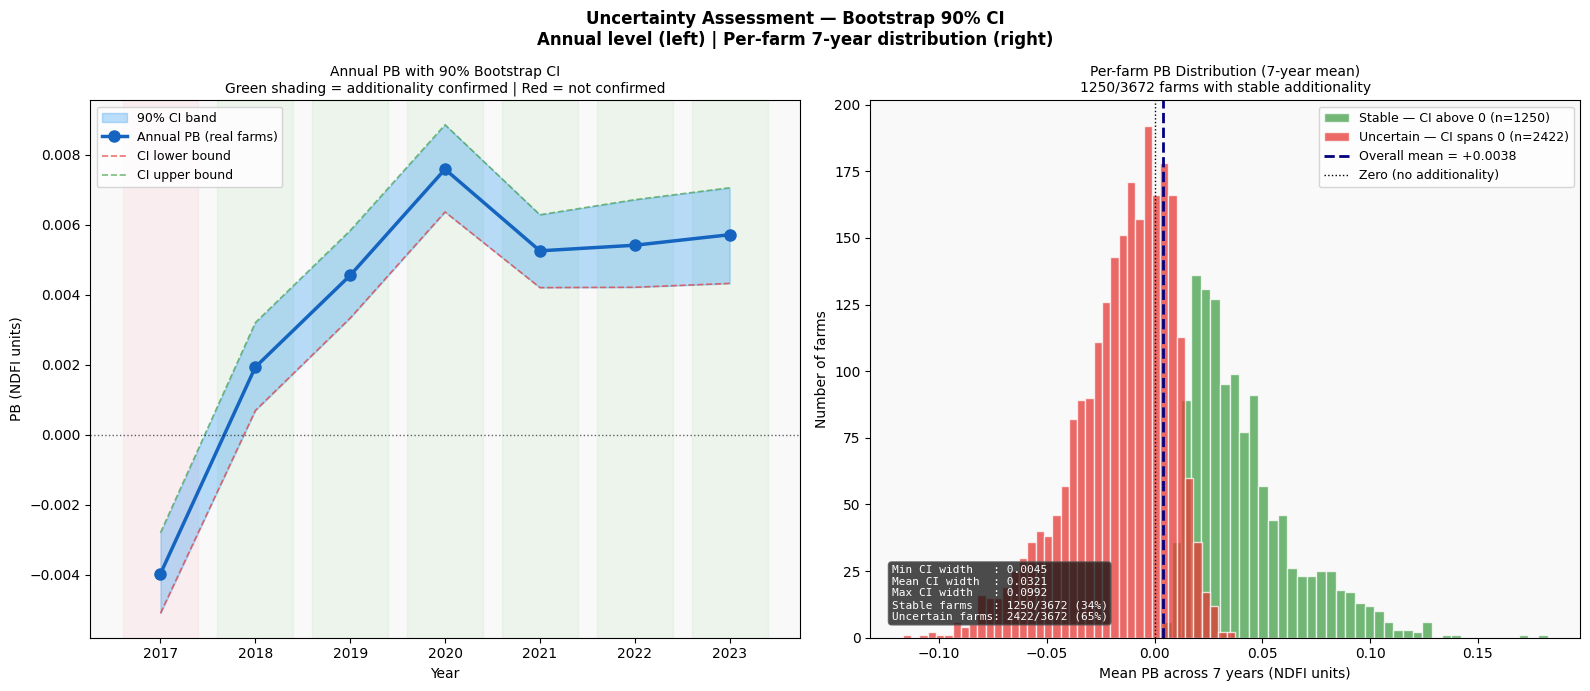

Uncertainty chart saved.


In [52]:
# Per-farm bootstrap CI across years
plot_pb_ts = {}
for res in annual_results:
    df_pp = res['per_plot']
    for _, row in df_pp.iterrows():
        key = (round(row['lon'], 4), round(row['lat'], 4))
        plot_pb_ts.setdefault(key, []).append(row['pb'])

complete_plots = {k: v for k, v in plot_pb_ts.items() if len(v) == 7}
print(f'Farms with complete 7-year PB series: {len(complete_plots)}')

rng   = np.random.default_rng(42)
alpha = (1 - CI_LEVEL) / 2
per_farm_ci = []

for (lon, lat), pb_series in complete_plots.items():
    arr  = np.array(pb_series)
    boot = [np.random.choice(arr, size=len(arr), replace=True).mean()
            for _ in range(N_BOOT)]
    per_farm_ci.append({
        'lon':      lon,
        'lat':      lat,
        'mean_pb':  arr.mean(),
        'ci_lower': np.quantile(boot, alpha),
        'ci_upper': np.quantile(boot, 1 - alpha),
        'ci_width': np.quantile(boot, 1-alpha) - np.quantile(boot, alpha),
        'stable':   bool(np.quantile(boot, alpha) > 0),
    })

ci_df = pd.DataFrame(per_farm_ci)

n_stable   = int(ci_df['stable'].sum())
n_unstable = len(ci_df) - n_stable

print(f'Farms with stable additionality (CI above 0): {n_stable} / {len(ci_df)}')
print(f'Farms uncertain (CI spans 0)               : {n_unstable} / {len(ci_df)}')
print(f'Mean CI width: {ci_df["ci_width"].mean():.4f} NDFI units')
print()

fig9, axes9 = plt.subplots(1, 2, figsize=(16, 7))
fig9.suptitle('Uncertainty Assessment — Bootstrap 90% CI\n'
              'Annual level (left) | Per-farm 7-year distribution (right)',
              fontsize=12, fontweight='bold')

# ── Left panel: annual PB with CI band
ax9a = axes9[0]
ax9a.set_facecolor('#f9f9f9')

yrs = results_df['year'].values
pb  = results_df['pb'].values
lo  = results_df['ci_lower'].values
hi  = results_df['ci_upper'].values

ax9a.fill_between(yrs, lo, hi, alpha=0.3, color='#2196f3',
                  label='90% CI band')
ax9a.plot(yrs, pb,  'o-', color='#1565c0', lw=2.5, ms=8,
          label='Annual PB (real farms)')
ax9a.plot(yrs, lo, '--',  color='#e53935', lw=1.2, alpha=0.7,
          label='CI lower bound')
ax9a.plot(yrs, hi, '--',  color='#43a047', lw=1.2, alpha=0.7,
          label='CI upper bound')
ax9a.axhline(0, color='black', lw=1.0, ls=':', alpha=0.6)

# Shade confirmed vs not confirmed years
for _, row in results_df.iterrows():
    c = '#c8e6c9' if row['additionality'] else '#ffcdd2'
    ax9a.axvspan(row['year'] - 0.4, row['year'] + 0.4,
                 alpha=0.25, color=c, zorder=0)

ax9a.set_xlabel('Year', fontsize=10)
ax9a.set_ylabel('PB (NDFI units)', fontsize=10)
ax9a.set_xticks(YEARS)
ax9a.set_title('Annual PB with 90% Bootstrap CI\n'
               'Green shading = additionality confirmed | Red = not confirmed',
               fontsize=10)
ax9a.legend(fontsize=9, loc='upper left')

# ── Right panel: distribution of per-farm mean PBs 
ax9b = axes9[1]
ax9b.set_facecolor('#f9f9f9')

stable_pbs   = ci_df[ci_df['stable']]['mean_pb'].values
unstable_pbs = ci_df[~ci_df['stable']]['mean_pb'].values

ax9b.hist(stable_pbs,   bins=40, color='#43a047', alpha=0.75,
          label=f'Stable — CI above 0 (n={n_stable})',
          edgecolor='white')
ax9b.hist(unstable_pbs, bins=40, color='#e53935', alpha=0.75,
          label=f'Uncertain — CI spans 0 (n={n_unstable})',
          edgecolor='white')
ax9b.axvline(ci_df['mean_pb'].mean(), color='navy', lw=2.0, ls='--',
             label=f'Overall mean = {ci_df["mean_pb"].mean():+.4f}')
ax9b.axvline(0, color='black', lw=1.0, ls=':',
             label='Zero (no additionality)')

ax9b.set_xlabel('Mean PB across 7 years (NDFI units)', fontsize=10)
ax9b.set_ylabel('Number of farms', fontsize=10)
ax9b.set_title(f'Per-farm PB Distribution (7-year mean)\n'
               f'{n_stable}/{len(ci_df)} farms with stable additionality',
               fontsize=10)

# Legend
ax9b.legend(fontsize=9, loc='upper right')

# Stats box
ci_stats = (
    f'Min CI width   : {ci_df["ci_width"].min():.4f}\n'
    f'Mean CI width  : {ci_df["ci_width"].mean():.4f}\n'
    f'Max CI width   : {ci_df["ci_width"].max():.4f}\n'
    f'Stable farms   : {n_stable}/{len(ci_df)} '
    f'({100*n_stable//len(ci_df)}%)\n'
    f'Uncertain farms: {n_unstable}/{len(ci_df)} '
    f'({100*n_unstable//len(ci_df)}%)'
)
ax9b.text(0.03, 0.03, ci_stats,
          transform=ax9b.transAxes, fontsize=8,
          verticalalignment='bottom', horizontalalignment='left',
          fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='#111',
                    alpha=0.75, edgecolor='#555'),
          color='white')

plt.tight_layout()
plt.savefig('uncertainty_real.png', dpi=150, bbox_inches='tight')
plt.show()
print('Uncertainty chart saved.')

## 10. VM0047 Monitoring Summary

Final report for the Ghana farm dataset.


In [30]:
import json as _json; from datetime import date

if len(results_df) == 0:
    print('No results to summarise — run sections 7-9 first.')
else:
    mean_pb = results_df['pb'].mean()
    n_conf  = int(results_df['additionality'].sum())
    rng = np.random.default_rng(99)
    ob  = [results_df['pb'].sample(len(results_df), replace=True).mean()
           for _ in range(1000)]
    a    = (1 - CI_LEVEL) / 2
    o_lo = np.quantile(ob, a); o_hi = np.quantile(ob, 1-a)
    overall = bool(o_lo > 0)

    print('=' * 62)
    print('  VM0047 MONITORING SUMMARY — REAL GHANA FARM DATA')
    print('=' * 62)
    print(f'  Data source      : RAMANI B.V. farm polygon GeoJSON')
    print(f'  Project plots    : {len(low_merged)} low-deforestation farms')
    print(f'  Donor pool       : {len(high_merged)} high-deforestation farms')
    print(f'  Regions          : '
          f'{set(list(low_merged.region)+list(high_merged.region))}')
    print(f'  Stocking index   : NDFI (proxy, not yet tCO2e)')
    print(f'  Matching method  : k-NN k={K_NEIGHBOURS}, '
          f'region-filtered, location-based')
    print()
    print(f'  Mean annual PB   : {mean_pb:+.5f} NDFI units')
    print(f'  Years PB > 0     : '
          f'{int((results_df["pb"]>0).sum())} / {len(results_df)}')
    print(f'  Additionality    : {n_conf} / {len(results_df)} years confirmed')
    print(f'  90% CI (overall) : [{o_lo:+.5f}, {o_hi:+.5f}]')
    print(f'  OVERALL RESULT   : '
          f'{"ADDITIONALITY CONFIRMED" if overall else "NOT CONFIRMED"}')
    print()
    print(f'  {"Year":6} {"PB":>10} {"CI lower":>10} {"CI upper":>10} '
          f'{"n farms":>8} {"Result":>14}')
    print('  ' + '-'*65)
    for _, r in results_df.iterrows():
        print(f'  {int(r["year"]):6d} {r["pb"]:+10.5f} '
              f'{r["ci_lower"]:+10.5f} {r["ci_upper"]:+10.5f} '
              f'{int(r["n_matched"]):8d} '
              f'{"CONFIRMED" if r["additionality"] else "not confirmed":>14}')
    print()
    print('Next step: convert NDFI benchmark to tCO2e/ha using')
    print('NDFI-AGB regression calibrated on field measurements.')

    # JSON-LD export
    doc = {'@context': {'@vocab': 'https://ramani.bv/bok/concepts/',
                        'vm0047': 'https://verra.org/methodology/vm0047#',
                        'dcterms': 'http://purl.org/dc/terms/'},
           'dcterms:title':   'DPB Results — Real Ghana Farm Data',
           'dcterms:creator': 'Collins Edem Hlordzie',
           'dcterms:date':    str(date.today()),
           'data_source':     'RAMANI B.V. GeoJSON + Farmer Survey',
           'n_project_farms': len(low_merged),
           'n_donor_farms':   len(high_merged),
           'vm0047:PerformanceBenchmark': {
               'overall_pb':    round(mean_pb, 6),
               'ci_lower':      round(o_lo, 6),
               'ci_upper':      round(o_hi, 6),
               'additionality': overall},
           'vm0047:AnnualResults': [
               {'year': int(r['year']), 'pb': r['pb'],
                'ci_lower': r['ci_lower'], 'ci_upper': r['ci_upper'],
                'vm0047:Additionality': bool(r['additionality'])}
               for _, r in results_df.iterrows()]}
    with open('dpb_real_results.jsonld', 'w') as f:
        _json.dump(doc, f, indent=2)
    print('JSON-LD written: dpb_real_results.jsonld')


  VM0047 MONITORING SUMMARY — REAL GHANA FARM DATA
  Data source      : RAMANI B.V. farm polygon GeoJSON
  Project plots    : 3672 low-deforestation farms
  Donor pool       : 2082 high-deforestation farms
  Regions          : {'Bono East ', nan, 'Bono '}
  Stocking index   : NDFI (proxy, not yet tCO2e)
  Matching method  : k-NN k=3, region-filtered, location-based

  Mean annual PB   : +0.00378 NDFI units
  Years PB > 0     : 6 / 7
  Additionality    : 6 / 7 years confirmed
  90% CI (overall) : [+0.00150, +0.00576]
  OVERALL RESULT   : ADDITIONALITY CONFIRMED

  Year           PB   CI lower   CI upper  n farms         Result
  -----------------------------------------------------------------
    2017   -0.00397   -0.00514   -0.00289     3672  not confirmed
    2018   +0.00193   +0.00057   +0.00332     3672      CONFIRMED
    2019   +0.00455   +0.00332   +0.00572     3672      CONFIRMED
    2020   +0.00758   +0.00628   +0.00887     3672      CONFIRMED
    2021   +0.00525   +0.00431   +

## Build a Vocabulary File

In [54]:
skos_ttl = """\
@prefix skos:    <http://www.w3.org/2004/02/skos/core#> .
@prefix ram:     <https://ramani.bv/bok/concepts/> .
@prefix vm0047:  <https://verra.org/methodology/vm0047#> .
@prefix ofp:     <https://openforestprotocol.org/vocab#> .
@prefix gs:      <https://goldstandard.org/vocab#> .
@prefix dcterms: <http://purl.org/dc/terms/> .
@prefix rdfs:    <http://www.w3.org/2000/01/rdf-schema#> .

# ── Concept scheme ────────────────────────────────────────────────────────
ram:DPBConceptScheme
    a skos:ConceptScheme ;
    dcterms:title "DPB Carbon Standards Vocabulary" ;
    dcterms:creator "Collins Edem Hlordzie" ;
    dcterms:description "SKOS vocabulary mapping DPB concepts across VM0047, OFP, and Gold Standard." .

# ── 1. Performance Benchmark ──────────────────────────────────────────────
ram:performance_benchmark
    a skos:Concept ;
    skos:inScheme ram:DPBConceptScheme ;
    skos:prefLabel "Performance Benchmark (PB)"@en ;
    skos:definition "Difference in stocking index between project plots and matched control plots. Positive value indicates additionality."@en ;
    skos:exactMatch vm0047:PerformanceBenchmark ;
    skos:closeMatch ofp:ProjectVsBaselinePerformance ;
    skos:closeMatch gs:AdditionalityIndicator .

# ── 2. Stocking Index ─────────────────────────────────────────────────────
ram:stocking_index
    a skos:Concept ;
    skos:inScheme ram:DPBConceptScheme ;
    skos:prefLabel "Stocking Index (NDFI)"@en ;
    skos:definition "Spectral proxy for vegetation density and woody biomass derived from satellite imagery. NDFI preferred over NDVI for tropical forest."@en ;
    skos:exactMatch vm0047:StockingIndex ;
    skos:closeMatch ofp:VegetationIndex ;
    skos:closeMatch gs:VegetationCoverProxy .

# ── 3. Donor Pool ─────────────────────────────────────────────────────────
ram:donor_pool
    a skos:Concept ;
    skos:inScheme ram:DPBConceptScheme ;
    skos:prefLabel "Donor Pool"@en ;
    skos:definition "Full set of candidate control plots drawn from unmanaged surrounding landscape before categorical filtering."@en ;
    skos:exactMatch vm0047:DonorPool ;
    skos:closeMatch ofp:ReferenceAreaPool ;
    skos:closeMatch gs:BaselineReferencePool .

# ── 4. Matched Control Plots ──────────────────────────────────────────────
ram:matched_control_plots
    a skos:Concept ;
    skos:inScheme ram:DPBConceptScheme ;
    skos:prefLabel "Matched Control Plots"@en ;
    skos:definition "Subset of donor pool selected via k-NN matching as the counterfactual comparison group for project plots."@en ;
    skos:exactMatch vm0047:MatchedControlPlots ;
    skos:closeMatch ofp:ReferencePlots ;
    skos:closeMatch gs:BaselineScenarioPlots .

# ── 5. Categorical Filter ─────────────────────────────────────────────────
ram:categorical_filter
    a skos:Concept ;
    skos:inScheme ram:DPBConceptScheme ;
    skos:prefLabel "Categorical Covariate Filter"@en ;
    skos:definition "Pre-matching filter restricting donor pool to plots sharing the same ecoregion and land tenure as project plots."@en ;
    skos:exactMatch vm0047:CategoricalVariables ;
    skos:exactMatch ofp:StratificationVariables ;
    skos:exactMatch gs:BaselineStratificationCriteria .

# ── 6. k-NN Matching ──────────────────────────────────────────────────────
ram:knn_matching
    a skos:Concept ;
    skos:inScheme ram:DPBConceptScheme ;
    skos:prefLabel "k-NN Matching Process"@en ;
    skos:definition "Nearest-neighbour algorithm selecting k control plots most similar to each project plot on location covariates."@en ;
    skos:exactMatch vm0047:MultivariateMatching ;
    skos:closeMatch ofp:PlotMatching ;
    skos:closeMatch gs:ComparativeSiteAnalysis .

# ── 7. Confidence Interval ────────────────────────────────────────────────
ram:confidence_interval
    a skos:Concept ;
    skos:inScheme ram:DPBConceptScheme ;
    skos:prefLabel "90% Confidence Interval"@en ;
    skos:definition "Range within which the true PB falls with 90% probability, computed via bootstrap resampling. Required at Tier 2."@en ;
    skos:exactMatch vm0047:ConfidenceInterval ;
    skos:exactMatch ofp:ConfidenceInterval ;
    skos:exactMatch gs:ConfidenceInterval .

# ── 8. Additionality ─────────────────────────────────────────────────────
ram:additionality
    a skos:Concept ;
    skos:inScheme ram:DPBConceptScheme ;
    skos:prefLabel "Additionality"@en ;
    skos:definition "Carbon removal that would not have occurred without the project. Confirmed when PB > 0 and 90% CI entirely above zero."@en ;
    skos:closeMatch vm0047:Additionality ;
    skos:closeMatch ofp:Additionality ;
    skos:closeMatch gs:Additionality .

# ── 9. Balance Check ─────────────────────────────────────────────────────
ram:balance_check
    a skos:Concept ;
    skos:inScheme ram:DPBConceptScheme ;
    skos:prefLabel "Balance Check"@en ;
    skos:definition "Post-matching diagnostic confirming project and control groups are comparable. VM0047 threshold: standardised difference < 0.25."@en ;
    skos:exactMatch vm0047:StandardisedDifference ;
    skos:closeMatch ofp:CovariateBalanceAssessment ;
    skos:closeMatch gs:BaselineComparabilityCheck .

# ── 10. Dynamic Baseline ─────────────────────────────────────────────────
ram:dynamic_baseline
    a skos:Concept ;
    skos:inScheme ram:DPBConceptScheme ;
    skos:prefLabel "Dynamic Baseline"@en ;
    skos:definition "Baseline derived from current satellite observations of comparable unmanaged land, updated annually. Specific to VM0047."@en ;
    skos:exactMatch vm0047:DynamicBaseline ;
    skos:note "No direct equivalent in OFP or Gold Standard — both use static historical baselines."@en .
"""

with open('carbon_standards_skos.ttl', 'w') as f:
    f.write(skos_ttl)

print('SKOS vocabulary written: carbon_standards_skos.ttl')
print('Concepts defined: 10')
print('Standards covered: VM0047, OFP, Gold Standard')

SKOS vocabulary written: carbon_standards_skos.ttl
Concepts defined: 10
Standards covered: VM0047, OFP, Gold Standard


## Annotate DPB outputs with cross-standard URIs

In [56]:
import json
from datetime import date

# ── Concept registry  ────────────────────
CONCEPTS = {
    'performance_benchmark': {
        'prefLabel':  'Performance Benchmark (PB)',
        'definition': 'Difference in stocking index between project plots '
                      'and matched control plots.',
        'vm0047': {'uri': 'https://verra.org/methodology/vm0047#PerformanceBenchmark',
                   'term': 'Performance Benchmark', 'match': 'exact'},
        'ofp':    {'uri': 'https://openforestprotocol.org/vocab#ProjectVsBaselinePerformance',
                   'term': 'Project vs Baseline Performance', 'match': 'close'},
        'gs':     {'uri': 'https://goldstandard.org/vocab#AdditionalityIndicator',
                   'term': 'Additionality Performance Indicator', 'match': 'close'},
    },
    'stocking_index': {
        'prefLabel':  'Stocking Index (NDFI)',
        'definition': 'Spectral proxy for vegetation density and woody biomass.',
        'vm0047': {'uri': 'https://verra.org/methodology/vm0047#StockingIndex',
                   'term': 'Stocking Index', 'match': 'exact'},
        'ofp':    {'uri': 'https://openforestprotocol.org/vocab#VegetationIndex',
                   'term': 'Vegetation Index', 'match': 'close'},
        'gs':     {'uri': 'https://goldstandard.org/vocab#VegetationCoverProxy',
                   'term': 'Vegetation Cover Proxy', 'match': 'close'},
    },
    'donor_pool': {
        'prefLabel':  'Donor Pool',
        'definition': 'Candidate control plots from unmanaged surrounding landscape.',
        'vm0047': {'uri': 'https://verra.org/methodology/vm0047#DonorPool',
                   'term': 'Donor Pool', 'match': 'exact'},
        'ofp':    {'uri': 'https://openforestprotocol.org/vocab#ReferenceAreaPool',
                   'term': 'Reference Area Pool', 'match': 'close'},
        'gs':     {'uri': 'https://goldstandard.org/vocab#BaselineReferencePool',
                   'term': 'Baseline Reference Pool', 'match': 'close'},
    },
    'matched_controls': {
        'prefLabel':  'Matched Control Plots',
        'definition': 'k-NN selected counterfactual comparison group.',
        'vm0047': {'uri': 'https://verra.org/methodology/vm0047#MatchedControlPlots',
                   'term': 'Matched Control Plots', 'match': 'exact'},
        'ofp':    {'uri': 'https://openforestprotocol.org/vocab#ReferencePlots',
                   'term': 'Reference Plots', 'match': 'close'},
        'gs':     {'uri': 'https://goldstandard.org/vocab#BaselineScenarioPlots',
                   'term': 'Baseline Scenario Plots', 'match': 'close'},
    },
    'categorical_filter': {
        'prefLabel':  'Categorical Covariate Filter',
        'definition': 'Pre-matching filter on ecoregion and land tenure.',
        'vm0047': {'uri': 'https://verra.org/methodology/vm0047#CategoricalVariables',
                   'term': 'Categorical Variables', 'match': 'exact'},
        'ofp':    {'uri': 'https://openforestprotocol.org/vocab#StratificationVariables',
                   'term': 'Stratification Variables', 'match': 'exact'},
        'gs':     {'uri': 'https://goldstandard.org/vocab#BaselineStratificationCriteria',
                   'term': 'Baseline Stratification Criteria', 'match': 'exact'},
    },
    'knn_matching': {
        'prefLabel':  'k-NN Matching',
        'definition': 'k=3 nearest neighbours on location. NDFI excluded.',
        'vm0047': {'uri': 'https://verra.org/methodology/vm0047#MultivariateMatching',
                   'term': 'Multivariate Matching', 'match': 'exact'},
        'ofp':    {'uri': 'https://openforestprotocol.org/vocab#PlotMatching',
                   'term': 'Plot Matching', 'match': 'close'},
        'gs':     {'uri': 'https://goldstandard.org/vocab#ComparativeSiteAnalysis',
                   'term': 'Comparative Site Analysis', 'match': 'close'},
    },
    'confidence_interval': {
        'prefLabel':  '90% Confidence Interval',
        'definition': 'Bootstrap 90% CI. Required at VM0047 Tier 2.',
        'vm0047': {'uri': 'https://verra.org/methodology/vm0047#ConfidenceInterval',
                   'term': '90% CI (Tier 2)', 'match': 'exact'},
        'ofp':    {'uri': 'https://openforestprotocol.org/vocab#ConfidenceInterval',
                   'term': '90% CI', 'match': 'exact'},
        'gs':     {'uri': 'https://goldstandard.org/vocab#ConfidenceInterval',
                   'term': '90% CI', 'match': 'exact'},
    },
    'additionality': {
        'prefLabel':  'Additionality',
        'definition': 'PB > 0 with CI entirely above zero.',
        'vm0047': {'uri': 'https://verra.org/methodology/vm0047#Additionality',
                   'term': 'Additionality (DPB)', 'match': 'close'},
        'ofp':    {'uri': 'https://openforestprotocol.org/vocab#Additionality',
                   'term': 'Additionality (counterfactual rate)', 'match': 'close'},
        'gs':     {'uri': 'https://goldstandard.org/vocab#Additionality',
                   'term': 'Additionality (CDM tool)', 'match': 'close'},
    },
    'balance_check': {
        'prefLabel':  'Balance Check',
        'definition': 'Standardised difference of means < 0.25.',
        'vm0047': {'uri': 'https://verra.org/methodology/vm0047#StandardisedDifference',
                   'term': 'Std diff < 0.25', 'match': 'exact'},
        'ofp':    {'uri': 'https://openforestprotocol.org/vocab#CovariateBalanceAssessment',
                   'term': 'Covariate Balance Assessment', 'match': 'close'},
        'gs':     {'uri': 'https://goldstandard.org/vocab#BaselineComparabilityCheck',
                   'term': 'Baseline Comparability Check', 'match': 'close'},
    },
    'dynamic_baseline': {
        'prefLabel':  'Dynamic Baseline',
        'definition': 'Annually updated baseline from satellite obs. VM0047-specific.',
        'vm0047': {'uri': 'https://verra.org/methodology/vm0047#DynamicBaseline',
                   'term': 'Dynamic Performance Baseline', 'match': 'exact'},
        'ofp':    {'uri': None,
                   'term': 'No equivalent (uses static historical baseline)',
                   'match': 'none'},
        'gs':     {'uri': None,
                   'term': 'No equivalent (uses static modelled baseline)',
                   'match': 'none'},
    },
}

def annotate(concept_key, value, unit='', method='', extra=None):
    c = CONCEPTS[concept_key]
    record = {
        '@type':      'skos:Concept',
        '@id':        f'https://ramani.bv/bok/concepts/{concept_key}',
        'prefLabel':  c['prefLabel'],
        'definition': c['definition'],
        'value':      round(float(value), 6) if isinstance(value, float) else value,
        'unit':       unit,
        'method':     method,
        'date':       str(date.today()),
        'standards': {
            'VM0047':       c['vm0047'],
            'OFP':          c['ofp'],
            'GoldStandard': c['gs'],
        }
    }
    if extra:
        record.update(extra)
    return record

# ── Build annotated output document ──────────────────────────────────────
mean_pb = results_df['pb'].mean()
rng = np.random.default_rng(99)
ob  = [results_df['pb'].sample(len(results_df), replace=True).mean()
       for _ in range(1000)]
a   = (1 - CI_LEVEL) / 2
o_lo = np.quantile(ob, a)
o_hi = np.quantile(ob, 1 - a)
overall_add = bool(o_lo > 0)

ANNOTATED = []

ANNOTATED.append(annotate(
    'stocking_index', 'NDFI',
    unit='dimensionless index [-1, 1]',
    method='(NIR - SWIR1) / (NIR + SWIR1), Landsat 8 Band 5 and Band 6',
    extra={'sensor': 'Landsat 8 Collection 2 SR',
           'period': '2017-2023',
           'compositing': 'annual cloud-free median'}))

ANNOTATED.append(annotate(
    'donor_pool', len(high_merged),
    unit='farms',
    method='High-deforestation farms from RAMANI GeoJSON — All_Farms file',
    extra={'n_project_farms': len(low_merged), 'k': K_NEIGHBOURS}))

ANNOTATED.append(annotate(
    'categorical_filter',
    'region match + latitude band fallback (±0.2°)',
    unit='categorical',
    method='Exact region match from survey join; lat-band proxy where survey unavailable',
    extra={'primary_filter': 'region', 'fallback_filter': 'latitude band ±0.2°'}))

ANNOTATED.append(annotate(
    'knn_matching', len(low_merged),
    unit='project farms matched',
    method='sklearn NearestNeighbors k=3, Euclidean on standardised (lon, lat)',
    extra={'k': K_NEIGHBOURS,
           'matching_variables': ['longitude', 'latitude'],
           'excluded': 'NDFI — excluded to preserve additionality signal'}))

ANNOTATED.append(annotate(
    'performance_benchmark', round(mean_pb, 6),
    unit='NDFI index units',
    method='mean(project NDFI) - mean(matched control NDFI) per farm, then overall mean',
    extra={'years_pb_positive':     int((results_df['pb'] > 0).sum()),
           'years_total':           len(results_df),
           'n_farms':               len(low_merged),
           'note': 'NDFI proxy units only — tCO2e conversion requires field calibration'}))

ANNOTATED.append(annotate(
    'confidence_interval', round(mean_pb, 6),
    unit='NDFI index units',
    method='Bootstrap resampling n=1000, 90% CI on annual PB means',
    extra={'ci_lower':    round(o_lo, 6),
           'ci_upper':    round(o_hi, 6),
           'ci_level':    CI_LEVEL,
           'n_bootstrap': 1000,
           'ci_above_zero': overall_add}))

ANNOTATED.append(annotate(
    'balance_check',
    'passed' if results_df['balance_pass'].all() else 'failed in some years',
    unit='standardised difference of means',
    method='Rosenbaum & Rubin (1985) — threshold 0.25',
    extra={'threshold': 0.25,
           'years_passed': int(results_df['balance_pass'].sum()),
           'years_total':  len(results_df)}))

ANNOTATED.append(annotate(
    'additionality',
    'CONFIRMED' if overall_add else 'NOT CONFIRMED',
    unit='',
    method='PB > 0 AND 90% CI entirely above zero across 7-year monitoring period',
    extra={'pb_positive':    bool(mean_pb > 0),
           'ci_above_zero':  overall_add,
           'years_confirmed': int(results_df['additionality'].sum()),
           'years_total':     len(results_df)}))

ANNOTATED.append(annotate(
    'dynamic_baseline', 'Annual Landsat 8 NDFI composite',
    unit='NDFI per year',
    method='GEE annual median composite of matched donor pool plots',
    extra={'reference_year': 2000,
           'monitoring_start': 2017,
           'monitoring_end': 2023,
           'note': 'Forest_2000_ha field anchors carbon stock to year-2000 Hansen baseline'}))

print(f'Annotated outputs: {len(ANNOTATED)}')
print()
for o in ANNOTATED:
    v_str = str(o['value'])[:20]
    print(f"  {o['prefLabel']:40s} value={v_str}")
    for std, info in o['standards'].items():
        match = info.get('match', 'none')
        term  = info.get('term', '')
        col   = {'exact': '✓', 'close': '~', 'none': '✗'}.get(match, '?')
        print(f"    {col} {std:15s} ({match:5s}): {term}")
    print()

Annotated outputs: 9

  Stocking Index (NDFI)                    value=NDFI
    ✓ VM0047          (exact): Stocking Index
    ~ OFP             (close): Vegetation Index
    ~ GoldStandard    (close): Vegetation Cover Proxy

  Donor Pool                               value=2082
    ✓ VM0047          (exact): Donor Pool
    ~ OFP             (close): Reference Area Pool
    ~ GoldStandard    (close): Baseline Reference Pool

  Categorical Covariate Filter             value=region match + latit
    ✓ VM0047          (exact): Categorical Variables
    ✓ OFP             (exact): Stratification Variables
    ✓ GoldStandard    (exact): Baseline Stratification Criteria

  k-NN Matching                            value=3672
    ✓ VM0047          (exact): Multivariate Matching
    ~ OFP             (close): Plot Matching
    ~ GoldStandard    (close): Comparative Site Analysis

  Performance Benchmark (PB)               value=0.00378
    ✓ VM0047          (exact): Performance Benchmark
    ~ OF

## Export to JSON-LD

In [57]:
JSONLD_CONTEXT = {
    '@vocab':       'https://ramani.bv/bok/concepts/',
    'skos':         'http://www.w3.org/2004/02/skos/core#',
    'prov':         'http://www.w3.org/ns/prov#',
    'dcterms':      'http://purl.org/dc/terms/',
    'vm0047':       'https://verra.org/methodology/vm0047#',
    'ofp':          'https://openforestprotocol.org/vocab#',
    'gs':           'https://goldstandard.org/vocab#',
    'prefLabel':    'skos:prefLabel',
    'definition':   'skos:definition',
    'exactMatch':   'skos:exactMatch',
    'closeMatch':   'skos:closeMatch',
}

jsonld_doc = {
    '@context':          JSONLD_CONTEXT,
    '@type':             'prov:Bundle',
    'dcterms:title':     'DPB Outputs — Semantic Uplift',
    'dcterms:creator':   'Collins Edem Hlordzie',
    'dcterms:date':      str(date.today()),
    'dcterms:subject':   'Nature-based Carbon Removal / ARR / DPB',
    'dcterms:publisher': 'RAMANI B.V.',
    'area':              'Bono and Bono East, Ghana',
    'period':            '2017-2023',
    'n_project_farms':   len(low_merged),
    'n_donor_farms':     len(high_merged),
    'prov:wasAttributedTo': {
        '@type':      'prov:Agent',
        'name':       'RAMANI B.V.',
        'supervisor': 'Valentijn Venus'
    },
    'outputs': ANNOTATED,
    'annualResults': [
        {
            'year':                  int(r['year']),
            'vm0047:PB':             r['pb'],
            'ci_lower':              r['ci_lower'],
            'ci_upper':              r['ci_upper'],
            'vm0047:Additionality':  bool(r['additionality']),
            'ofp:Additionality':     bool(r['additionality']),
            'gs:Additionality':      bool(r['additionality']),
            'balance_check':         r['balance'],
            'balance_pass':          bool(r['balance_pass']),
            'n_matched_farms':       int(r['n_matched']),
        }
        for _, r in results_df.iterrows()
    ]
}

with open('dpb_semantic_outputs.jsonld', 'w') as f:
    json.dump(jsonld_doc, f, indent=2)

print('JSON-LD written: dpb_semantic_outputs.jsonld')
print(f'  Concepts annotated : {len(ANNOTATED)}')
print(f'  Annual results     : {len(results_df)}')
print(f'  Standards covered  : VM0047, OFP, Gold Standard')
print(f'  File size          : {len(json.dumps(jsonld_doc))//1024} KB')

JSON-LD written: dpb_semantic_outputs.jsonld
  Concepts annotated : 9
  Annual results     : 7
  Standards covered  : VM0047, OFP, Gold Standard
  File size          : 9 KB


## Semantic Uplift -  interactive  vocabulary map 

In [6]:
from IPython.display import display, IFrame

vocab_map_html = """<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<style>
  body { font-family: Arial, sans-serif; background:#fff; color:#222; margin:0; padding:16px; }
  .controls { display:flex; gap:8px; flex-wrap:wrap; margin-bottom:12px; align-items:center; }
  .controls button { font-size:12px; padding:4px 14px; border-radius:20px; cursor:pointer;
    border:1px solid #ccc; background:#f5f5f5; color:#555; transition:all .15s; }
  .controls button.active { background:#1B3A6B; border-color:#1B3A6B; color:#fff; font-weight:bold; }
  .controls button:hover { border-color:#1B3A6B; color:#1B3A6B; }
  .legend-row { display:flex; gap:18px; flex-wrap:wrap; margin-bottom:10px;
    font-size:12px; color:#555; align-items:center; }
  .leg { display:flex; align-items:center; gap:5px; }
  .leg-dot { width:10px; height:10px; border-radius:50%; }
  #vmap { display:block; border:1px solid #e8e8e8; border-radius:10px; background:#fafafa; cursor:default; }
  .detail-panel { background:#f7f9fc; border-radius:8px; border:1px solid #e0e8f0;
    padding:14px 16px; margin-top:12px; font-size:13px; min-height:80px; }
  .dp-title { font-weight:bold; font-size:14px; color:#1B3A6B; margin-bottom:5px; }
  .dp-def   { color:#555; margin-bottom:10px; line-height:1.55; }
  .std-pills { display:flex; gap:7px; flex-wrap:wrap; }
  .pill { border-radius:20px; padding:3px 10px; font-size:11px;
    font-weight:bold; border:1px solid; display:inline-block; margin-bottom:4px; }
  .pill-exact { background:#e8f5e9; color:#1b5e20; border-color:#388e3c; }
  .pill-close { background:#fff8e1; color:#e65100; border-color:#f57c00; }
  .pill-none  { background:#f5f5f5; color:#757575; border-color:#bdbdbd; }
  .hint { font-size:11px; color:#aaa; text-align:center; margin-top:5px; }
</style>
</head>
<body>

<div class="controls">
  <span style="font-size:12px;color:#888;font-weight:bold">Filter:</span>
  <button id="btn-all"   class="active" onclick="setFilter('all')">All concepts</button>
  <button id="btn-exact" onclick="setFilter('exact')">Exact matches</button>
  <button id="btn-close" onclick="setFilter('close')">Close matches</button>
  <button id="btn-none"  onclick="setFilter('none')">No equivalent</button>
</div>

<div class="legend-row">
  <div class="leg"><div class="leg-dot" style="background:#2e7d32"></div>Exact match</div>
  <div class="leg"><div class="leg-dot" style="background:#ef6c00"></div>Close match</div>
  <div class="leg"><div class="leg-dot" style="background:#9e9e9e"></div>No equivalent</div>
  <div class="leg" style="margin-left:auto;font-size:11px;color:#aaa">
    Click a concept &middot; drag to pan &middot; scroll to zoom
  </div>
</div>

<svg id="vmap" width="100%" viewBox="0 0 720 520"></svg>
<p class="hint">10 DPB concepts mapped across VM0047 &middot; Open Forest Protocol &middot; Gold Standard</p>

<div class="detail-panel" id="dp">
  <div class="dp-title">Select a concept node to explore</div>
  <div class="dp-def">Click any circle to see its definition and cross-standard mappings.</div>
</div>

<script>
var CONCEPTS = [
  { id:'pb', short:['Performance','Benchmark'],
    label:'Performance Benchmark (PB)',
    def:'Difference in stocking index between project plots and matched controls. Positive value = additionality signal.',
    mappings:[
      {std:'VM0047',   term:'Performance Benchmark',              match:'exact', uri:'vm0047#PerformanceBenchmark'},
      {std:'OFP',      term:'Project vs Baseline Performance',    match:'close', uri:'ofp#ProjectVsBaseline'},
      {std:'Gold Std', term:'Additionality Performance Indicator',match:'close', uri:'gs#AdditionalityIndicator'}
    ]},
  { id:'ndfi', short:['Stocking','Index (NDFI)'],
    label:'Stocking Index - NDFI',
    def:'NDFI = (NIR-SWIR1)/(NIR+SWIR1). Spectral proxy for woody biomass. Preferred over NDVI for tropical forest.',
    mappings:[
      {std:'VM0047',   term:'Stocking Index',        match:'exact', uri:'vm0047#StockingIndex'},
      {std:'OFP',      term:'Vegetation Index',       match:'close', uri:'ofp#VegetationIndex'},
      {std:'Gold Std', term:'Vegetation Cover Proxy', match:'close', uri:'gs#VegetationCoverProxy'}
    ]},
  { id:'donor', short:['Donor','Pool'],
    label:'Donor Pool',
    def:'Full set of candidate control plots from unmanaged surrounding landscape, before categorical filtering.',
    mappings:[
      {std:'VM0047',   term:'Donor Pool of Candidate Control Sites', match:'exact', uri:'vm0047#DonorPool'},
      {std:'OFP',      term:'Reference Area Pool',                   match:'close', uri:'ofp#ReferenceAreaPool'},
      {std:'Gold Std', term:'Baseline Reference Pool',               match:'close', uri:'gs#BaselineReferencePool'}
    ]},
  { id:'knn', short:['k-NN','Matching'],
    label:'k-NN Matching',
    def:'k=3 nearest neighbours on standardised location (lon, lat). NDFI excluded from matching to preserve additionality signal.',
    mappings:[
      {std:'VM0047',   term:'Multivariate Distance Matching', match:'exact', uri:'vm0047#MultivariateMatching'},
      {std:'OFP',      term:'Plot Matching / Pairing',         match:'close', uri:'ofp#PlotMatching'},
      {std:'Gold Std', term:'Comparative Site Analysis',       match:'close', uri:'gs#ComparativeSiteAnalysis'}
    ]},
  { id:'cat', short:['Categorical','Filter'],
    label:'Categorical Covariate Filter',
    def:'Pre-matching filter: only donor plots sharing the same ecoregion and land tenure as each project plot are eligible.',
    mappings:[
      {std:'VM0047',   term:'Categorical Variables (ecoregion, tenure)', match:'exact', uri:'vm0047#CategoricalVariables'},
      {std:'OFP',      term:'Stratification Variables',                   match:'exact', uri:'ofp#StratificationVariables'},
      {std:'Gold Std', term:'Baseline Stratification Criteria',           match:'exact', uri:'gs#BaselineStratification'}
    ]},
  { id:'ci', short:['90%','Conf. Interval'],
    label:'90% Confidence Interval',
    def:'Bootstrap 90% CI on PB values. VM0047 Tier 2 mandatory requirement - CI must be entirely above zero for credit issuance.',
    mappings:[
      {std:'VM0047',   term:'90% CI (Tier 2)',         match:'exact', uri:'vm0047#ConfidenceInterval'},
      {std:'OFP',      term:'90% Confidence Interval', match:'exact', uri:'ofp#ConfidenceInterval'},
      {std:'Gold Std', term:'90% Confidence Interval', match:'exact', uri:'gs#ConfidenceInterval'}
    ]},
  { id:'add', short:['Addi-','tionality'],
    label:'Additionality',
    def:'Carbon removal that would not have occurred without the project. Confirmed when PB > 0 and 90% CI is entirely above zero.',
    mappings:[
      {std:'VM0047',   term:'Additionality (DPB mechanism)',      match:'close', uri:'vm0047#Additionality'},
      {std:'OFP',      term:'Additionality (counterfactual rate)', match:'close', uri:'ofp#Additionality'},
      {std:'Gold Std', term:'Additionality (CDM tool)',            match:'close', uri:'gs#Additionality'}
    ]},
  { id:'bal', short:['Balance','Check'],
    label:'Balance Check',
    def:'Standardised difference of means < 0.25 post-matching. Confirms project and control groups are statistically comparable.',
    mappings:[
      {std:'VM0047',   term:'Std diff of means < 0.25',    match:'exact', uri:'vm0047#StandardisedDifference'},
      {std:'OFP',      term:'Covariate Balance Assessment', match:'close', uri:'ofp#CovariateBalance'},
      {std:'Gold Std', term:'Baseline Comparability Check', match:'close', uri:'gs#BaselineComparability'}
    ]},
  { id:'dyn', short:['Dynamic','Baseline'],
    label:'Dynamic Baseline',
    def:'Annually updated baseline from current satellite observations of unprotected land. VM0047-specific.',
    mappings:[
      {std:'VM0047',   term:'Dynamic Performance Baseline',              match:'exact', uri:'vm0047#DynamicBaseline'},
      {std:'OFP',      term:'No equivalent (static historical baseline)', match:'none',  uri:null},
      {std:'Gold Std', term:'No equivalent (static modelled baseline)',   match:'none',  uri:null}
    ]},
  { id:'ctrl', short:['Matched','Controls'],
    label:'Matched Control Plots',
    def:'k-NN selected counterfactual comparison group for each project plot - the farms representing business-as-usual.',
    mappings:[
      {std:'VM0047',   term:'Matched Control Plots',  match:'exact', uri:'vm0047#MatchedControlPlots'},
      {std:'OFP',      term:'Reference Plots',         match:'close', uri:'ofp#ReferencePlots'},
      {std:'Gold Std', term:'Baseline Scenario Plots', match:'close', uri:'gs#BaselineScenarioPlots'}
    ]}
];

var STD_NODES = [
  {id:'VM0047',   label:'VM0047',       x:130, y:448, fc:'#1565c0', bc:'#e3f2fd'},
  {id:'OFP',      label:'OFP',           x:360, y:488, fc:'#2e7d32', bc:'#e8f5e9'},
  {id:'Gold Std', label:'Gold Standard', x:590, y:448, fc:'#e65100', bc:'#fff3e0'}
];

var MCOL = {exact:'#2e7d32', close:'#ef6c00', none:'#9e9e9e'};
var CX=360, CY=210, R=150, CR=44;
var filter='all', selected=null;
var tx=0, ty=0, sc=1, drag=null, wasDragging=false;

var NS='http://www.w3.org/2000/svg';
var svg=document.getElementById('vmap');

function mkEl(tag,a){
  a=a||{};
  var e=document.createElementNS(NS,tag);
  for(var k in a) e.setAttribute(k,a[k]);
  return e;
}

function mkDefs(){
  var d=mkEl('defs');
  ['exact','close','none'].forEach(function(m){
    var mk=mkEl('marker',{id:'arr-'+m,viewBox:'0 0 10 10',
      refX:'8',refY:'5',markerWidth:'5',markerHeight:'5',orient:'auto-start-reverse'});
    var p=mkEl('path',{d:'M2 2L8 5L2 8',fill:'none',
      stroke:MCOL[m],'stroke-width':'1.5','stroke-linecap':'round','stroke-linejoin':'round'});
    mk.appendChild(p); d.appendChild(mk);
  });
  return d;
}

function getTransformG(){
  return svg.querySelector('g#root');
}

function applyTransform(){
  var g=getTransformG();
  if(g) g.setAttribute('transform','translate('+tx+','+ty+') scale('+sc+')');
}

function render(){
  while(svg.children.length) svg.removeChild(svg.lastChild);
  svg.appendChild(mkDefs());

  var gAll=mkEl('g',{id:'root',transform:'translate('+tx+','+ty+') scale('+sc+')'});
  svg.appendChild(gAll);

  var gEdge=mkEl('g'); var gStd=mkEl('g');
  var gNode=mkEl('g'); gAll.appendChild(gEdge);
  gAll.appendChild(gStd); gAll.appendChild(gNode);

  var n=CONCEPTS.length;
  CONCEPTS.forEach(function(c,i){
    var angle=2*Math.PI*i/n - Math.PI/2;
    c._x=CX+R*Math.cos(angle);
    c._y=CY+R*Math.sin(angle);
  });

  STD_NODES.forEach(function(s){
    var g=mkEl('g',{cursor:'pointer'});
    var rect=mkEl('rect',{x:s.x-56,y:s.y-16,width:112,height:32,rx:16,
      fill:s.bc,stroke:s.fc,'stroke-width':'1.5'});
    var t=mkEl('text',{x:s.x,y:s.y+1,'text-anchor':'middle',
      'dominant-baseline':'central','font-size':'12','font-weight':'bold',
      fill:s.fc,'font-family':'Arial,sans-serif'});
    t.textContent=s.label;
    g.appendChild(rect); g.appendChild(t);
    (function(ss){ g.onclick=function(e){ e.stopPropagation(); showStdDetail(ss); }; })(s);
    gStd.appendChild(g);
  });

  CONCEPTS.forEach(function(c){
    var hasMatch=c.mappings.some(function(m){ return filter==='all'||m.match===filter; });
    if(!hasMatch && !(selected && selected.id===c.id)) return;

    c.mappings.forEach(function(m){
      if(filter!=='all' && m.match!==filter) return;
      var s=null;
      STD_NODES.forEach(function(n){ if(n.id===m.std) s=n; });
      if(!s) return;
      var dx=s.x-c._x, dy=(s.y-16)-c._y;
      var dist=Math.sqrt(dx*dx+dy*dy);
      var ux=dx/dist, uy=dy/dist;
      var x1=c._x+ux*(CR+2), y1=c._y+uy*(CR+2);
      var x2=s.x-ux*10,      y2=(s.y-16)-uy*10;
      var mx=(x1+x2)/2+uy*20, my=(y1+y2)/2-ux*20;
      var isSel=selected && selected.id===c.id;
      var op=selected?(isSel?1:0.08):(0.3);
      var sw=isSel?2.2:0.9;
      var p=mkEl('path',{
        d:'M'+x1+' '+y1+' Q'+mx+' '+my+' '+x2+' '+y2,
        fill:'none', stroke:MCOL[m.match], 'stroke-width':sw,
        opacity:op, 'marker-end':'url(#arr-'+m.match+')',
        'stroke-dasharray':m.match==='none'?'4 3':'none'
      });
      gEdge.appendChild(p);
    });

    var dominant='none';
    if(c.mappings.some(function(m){return m.match==='exact';})) dominant='exact';
    else if(c.mappings.some(function(m){return m.match==='close';})) dominant='close';

    var isSel=selected && selected.id===c.id;
    var op=(selected && !isSel)?0.3:1;

    var g=mkEl('g',{cursor:'pointer',opacity:op});
    var circ=mkEl('circle',{cx:c._x, cy:c._y, r:CR,
      fill:isSel?MCOL[dominant]:'#fff',
      stroke:MCOL[dominant], 'stroke-width':isSel?2.5:1.5});
    g.appendChild(circ);

    var lines=c.short;
    var baseY=c._y-(lines.length-1)*7;
    lines.forEach(function(line,li){
      var t=mkEl('text',{x:c._x, y:baseY+li*14,
        'text-anchor':'middle','dominant-baseline':'central',
        'font-size':'10.5','font-weight':isSel?'bold':'normal',
        fill:isSel?'#fff':'#222','font-family':'Arial,sans-serif'});
      t.textContent=line;
      g.appendChild(t);
    });

    (function(cc){ g.onclick=function(e){ e.stopPropagation(); selectConcept(cc); }; })(c);
    gNode.appendChild(g);
  });

  var cg=mkEl('g');
  cg.appendChild(mkEl('circle',{cx:CX,cy:CY,r:54,
    fill:'#fff',stroke:'#1B3A6B','stroke-width':'2'}));
  var ct1=mkEl('text',{x:CX,y:CY-7,'text-anchor':'middle',
    'dominant-baseline':'central','font-size':'13','font-weight':'bold',
    fill:'#1B3A6B','font-family':'Arial,sans-serif'});
  ct1.textContent='DPB';
  var ct2=mkEl('text',{x:CX,y:CY+8,'text-anchor':'middle',
    'dominant-baseline':'central','font-size':'11',fill:'#555',
    'font-family':'Arial,sans-serif'});
  ct2.textContent='vocabulary';
  cg.appendChild(ct1); cg.appendChild(ct2);
  gNode.appendChild(cg);
}

function selectConcept(c){
  selected=(selected && selected.id===c.id)?null:c;
  render(); updateDetail();
}

function showStdDetail(s){
  var exact=0,close=0,none=0;
  CONCEPTS.forEach(function(c){
    c.mappings.forEach(function(m){
      if(m.std===s.id){
        if(m.match==='exact') exact++;
        else if(m.match==='close') close++;
        else none++;
      }
    });
  });
  document.getElementById('dp').innerHTML=
    '<div class="dp-title" style="color:'+s.fc+'">'+s.label+'</div>'+
    '<div class="dp-def">Coverage across all 10 DPB concepts:</div>'+
    '<div class="std-pills">'+
    '<span class="pill pill-exact">&#10003; '+exact+' exact</span>'+
    '<span class="pill pill-close">~ '+close+' close</span>'+
    '<span class="pill pill-none">&#10007; '+none+' no equivalent</span>'+
    '</div>';
}

function updateDetail(){
  if(!selected){
    document.getElementById('dp').innerHTML=
      '<div class="dp-title">Select a concept node to explore</div>'+
      '<div class="dp-def">Click any circle to see its definition and cross-standard mappings.</div>';
    return;
  }
  var c=selected;
  var pills=c.mappings.map(function(m){
    var cls='pill pill-'+m.match;
    var icon=m.match==='exact'?'&#10003;':m.match==='close'?'~':'&#10007;';
    var uri=m.uri?'<span style="font-size:10px;color:#999;display:block;font-family:monospace">'+m.uri+'</span>':'';
    return '<span class="'+cls+'">'+icon+' <b>'+m.std+'</b><br>'+m.term+uri+'</span>';
  }).join('');
  document.getElementById('dp').innerHTML=
    '<div class="dp-title">'+c.label+'</div>'+
    '<div class="dp-def">'+c.def+'</div>'+
    '<div class="std-pills">'+pills+'</div>';
}

function setFilter(f){
  filter=f; selected=null;
  document.querySelectorAll('.controls button').forEach(function(b){
    b.classList.remove('active');
  });
  document.getElementById('btn-'+f).classList.add('active');
  render(); updateDetail();
}

svg.addEventListener('click',function(){
  selected=null; render(); updateDetail();
});

svg.addEventListener('mousedown',function(e){
  wasDragging=false;
  drag={sx:e.clientX-tx, sy:e.clientY-ty};
  svg.style.cursor='grabbing'; e.preventDefault();
});

svg.addEventListener('mousemove',function(e){
  if(!drag) return;
  wasDragging=true;
  tx=e.clientX-drag.sx; ty=e.clientY-drag.sy;
  applyTransform();
});

svg.addEventListener('mouseup',function(){
  drag=null; svg.style.cursor='default';
  setTimeout(function(){wasDragging=false;},50);
});

svg.addEventListener('mouseleave',function(){
  drag=null; svg.style.cursor='default';
});

svg.addEventListener('wheel',function(e){
  e.preventDefault();
  var d=e.deltaY>0?0.92:1.09;
  var rect=svg.getBoundingClientRect();
  var mx=(e.clientX-rect.left)*(720/rect.width);
  var my=(e.clientY-rect.top)*(520/rect.height);
  tx=mx-d*(mx-tx); ty=my-d*(my-ty);
  sc=Math.min(Math.max(sc*d,0.4),3.5);
  applyTransform();
},{passive:false});

render();
</script>
</body>
</html>"""

with open('vocabulary_map.html', 'w', encoding='utf-8') as f:
    f.write(vocab_map_html)

with open('vocabulary_map.html', 'w', encoding='utf-8') as f:
    f.write(vocab_map_html)

from IPython.display import display, HTML
display(HTML(vocab_map_html))